# Handling missing categorical data

#### Most frequent value (mode) -> should be for MCAR (missing completely at random) and the value for the mode should be higher than the rest of the distribution

#### Create another category as "missing" -> There are a lot of values missing, so we can't replace with mode. 

# Frequent Value imputation

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv('train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [27]:
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [28]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

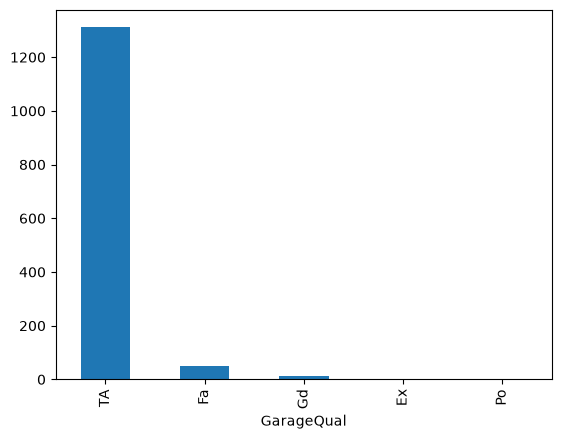

In [29]:
df['GarageQual'].value_counts().plot(kind='bar')

In [30]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: str

In [31]:
df['GarageQual'].fillna('TA', inplace=True)

/var/folders/sq/trq56hhj0ybb1s7606cjk3_00000gp/T/ipykernel_29218/1818999247.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['GarageQual'].fillna('TA', inplace=True)


0       TA
1       TA
2       TA
3       TA
4       TA
        ..
1455    TA
1456    TA
1457    TA
1458    TA
1459    TA
Name: GarageQual, Length: 1460, dtype: str

<Axes: xlabel='GarageQual'>

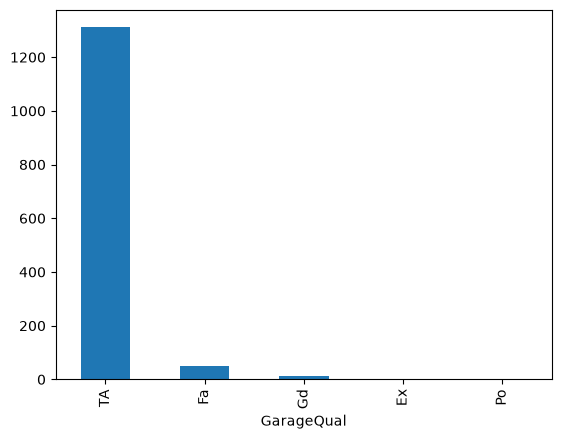

In [32]:
df['GarageQual'].value_counts().plot(kind='bar')

# Using Sklearn to perform same thing

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['SalePrice']), df['SalePrice'], test_size=0.2, random_state=0)

In [34]:
from sklearn.impute import SimpleImputer

In [35]:
imputer = SimpleImputer(strategy='most_frequent')

In [36]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.fit(X_test)

In [37]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['SalePrice']), df['SalePrice'], test_size=0.2, random_state=0)

In [39]:
imputer2 = SimpleImputer(strategy='constant', fill_value='Missing')

In [40]:
X_train = imputer2.fit_transform(X_train)
X_test = imputer2.fit(X_test)

In [41]:
imputer2.statistics_

array(['Missing', 'Missing'], dtype=object)